### Tasks

* 1. Download the 'Spotify Top 50 Songs' dataset from Kaggle, load it into a pandas DataFrame, and identify which columns should be used as features and which as the label if you want to predict a song's popularity score.*

In [4]:
import pandas as pd

In [5]:
df = pd.read_csv(r"C:\Users\patel prit\OneDrive\Desktop\Assessment\ML\Assignment\Supervised\Session - 2\Spotify.csv", encoding="latin1")

In [6]:
df.head()

,Column1,Track.Name,Artist.Name,Genre,Beats.Per.Minute,Energy,Danceability,Loudness..dB..,Liveness,Valence.,Length.,Acousticness..,Speechiness.,Popularity
0,1,SeÃ±orit,Shawn Mendes,canadian pop,117,55,76,-6,8,75,191,4,3,79
1,2,China,Anuel AA,reggaeton flow,105,81,79,-4,8,61,302,8,9,92
2,3,boyfriend (with Social House),Ariana Grande,dance pop,190,80,40,-4,16,70,186,12,46,85
3,4,Beautiful People (feat. Khalid),Ed Sheeran,pop,93,65,64,-8,8,55,198,12,19,86
4,5,Goodbyes (Feat. Young Thug),Post Malone,dfw rap,150,65,58,-4,11,18,175,45,7,94


In [7]:
df.columns

Index(['Column1', 'Track.Name', 'Artist.Name', 'Genre', 'Beats.Per.Minute',
       'Energy', 'Danceability', 'Loudness..dB..', 'Liveness', 'Valence.',
       'Length.', 'Acousticness..', 'Speechiness.', 'Popularity'],
      dtype='str')

In [8]:
df.isnull().sum()

Column1             0
Track.Name          0
Artist.Name         0
Genre               0
Beats.Per.Minute    0
Energy              0
Danceability        0
Loudness..dB..      0
Liveness            0
Valence.            0
Length.             0
Acousticness..      0
Speechiness.        0
Popularity          0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

### Split: X, y

In [10]:
X = df.drop('Popularity', axis=1)
y = df['Popularity']

* 2. Split the loaded Spotify dataset into training and test sets using sklearn's train_test_split function, with 80% for training and 20% for testing. Print the number of rows in each set.*

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [12]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (40, 13)
X_test: (10, 13)
y_train: (40,)
y_test: (10,)


* 3. Given a simple linear regression model predicting song popularity from danceability, intentionally use only 5% of the data for training and 95% for testing. Observe the model's performance and explain whether this is likely to cause underfitting or overfitting.*

In [13]:
X = df[['Danceability']]
y = df['Popularity']

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.05, random_state=42)

In [15]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

In [16]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [18]:
y_pred = model.predict(X_test)

In [29]:
from sklearn.metrics import r2_score

print("R² Score:",r2_score(y_test, y_pred))

R² Score: -1.928835563863566


In [17]:
print("Train Score:", model.score(X_train, y_train))
print("Test Score:", model.score(X_test, y_test))

Train Score: 0.014290858980238408
Test Score: -1.928835563863566


Explanation: The linear regression model was trained using only 5% of the dataset and tested on the remaining 95%. The model achieved a Train Score of 0.0143 and a Test Score of -1.9288. These results indicate very poor performance on both the training and testing data. Since the model was trained on a very small amount of data, it was unable to learn the relationship between danceability and popularity effectively. This is an example of **underfitting**, where the model is too simple or has insufficient training data to capture the underlying patterns in the dataset.

* 4. Draw or find a graph online that visually explains the bias–variance tradeoff, and write a short note describing how this tradeoff would affect predictions in a Zomato restaurant rating predictor app.*

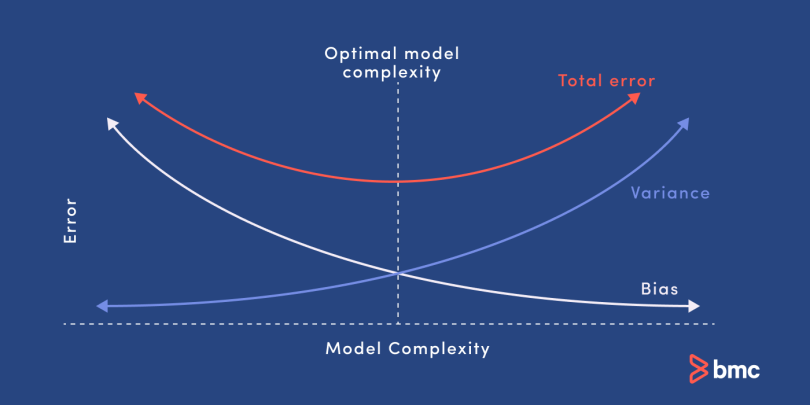

In [2]:
from IPython.display import Image, display

display(Image(filename="bias-and-variance.png"))

* 5. Give a real example (outside of healthcare/hospital) of overfitting from any app you use (e.g., Instagram, Flipkart, Swiggy), and explain in 2-3 lines why it might happen in that scenario.*

A: Flipkart Example:

If you search for headphones once and Flipkart continues recommending only headphones for many days, the recommendation system may be considered overfitted.

This happens because the model relies too heavily on your past search behavior and fails to generalize to your changing interests or current needs. As a result, it may ignore other products that could be relevant to you.